**ETL Pipeline**

In [ ]:
import os
import pandas as pd

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

from torchvision.transforms import transforms, ToTensor
from torchvision.io import read_image

In [ ]:
torch.__version__

'2.0.0+cu118'

In [ ]:
!pwd

/content


In [ ]:
!pip install transformers

In [ ]:
!ls

jh_floor_signs.csv  resized_jh_signs  sample_data


In [ ]:
total = 0
df = pd.read_csv('jh_floor_signs.csv', on_bad_lines='skip')
total = df.shape[0]
print(total)

100


In [ ]:
# Total no. of training files
_, _, training_files = next(os.walk('/content/resized_jh_signs/train'))
train_file_count = len(training_files)
print(train_file_count)

80


In [ ]:
# Total no. of testing files
_, _, testing_files = next(os.walk('/content/resized_jh_signs/test'))
test_file_count = len(testing_files)
print(test_file_count)

20


In [ ]:
def word_counter(text):
    word_num = len(text.split())
    return word_num

In [ ]:
max_seq_len = df['context'].map(word_counter).max() + 17

In [ ]:
max_seq_len

30

In [ ]:
def generate_id_and_file_list(files):
    id_and_file_list = list()
    for file in files:
        image_details = file.split('.')
        id_and_file_list.append({
            'id': image_details[0].split('_')[2],
            'name': f'{image_details[0]}.{image_details[1]}'
        })

    return id_and_file_list

In [ ]:
train_id_and_file_list = generate_id_and_file_list(training_files)

In [ ]:
test_id_and_file_list = generate_id_and_file_list(testing_files)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [ ]:
def show_image(image, target_bbox, pred_bbox):

    fig, ax = plt.subplots()
    ax.imshow(np.array(image)[::-1], origin='lower')

    # target_bbox
    (x,y,w,h) = target_bbox
    x,y,w,h = np.array([x,y,w,h])
    x1 = x
    y1 = y

    rect = patches.Rectangle((x1, y1), w, h, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    # pred_bbox
    (p,q,a,b) = pred_bbox
    p,q,a,b = np.array([p,q,a,b])
    p1 = p
    q1 = q

    pact = patches.Rectangle((p1, q1), a, b, linewidth=1, edgecolor='b', facecolor='none')
    ax.add_patch(pact)

    plt.show()

In [ ]:
image = Image.open(os.path.join('/content/resized_jh_signs/test', testing_files[0])).convert('RGB')
print(image.size)

image_details = df[df['id'] == int(test_id_and_file_list[0]['id'])]


#target_bbox
x = image_details['bbox_x'].values[0]
y = image_details['bbox_y'].values[0]
w = image_details['bbox_width'].values[0]
h = image_details['bbox_height'].values[0]
c = (x, y, w, h)

(720, 540)


In [ ]:
p = x + 10
q = y + 10
a = w + 10
b = h + 10
d = (p, q, a, b)

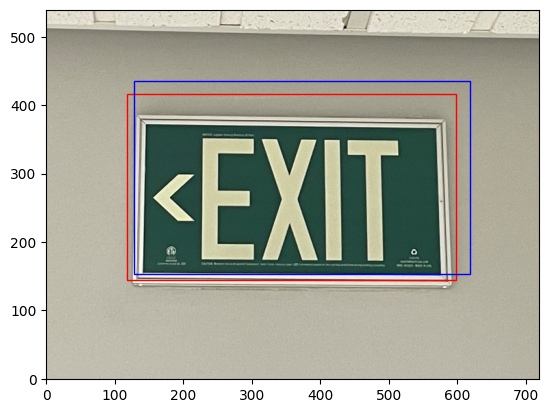

In [ ]:
show_image(image, c, d)

**Custom Dataset**

In [ ]:
class IndoorSignDetectionDataset(Dataset):
    def __init__(self, base_dir, img_dir, csv_file, id_and_file_list,
                 tokenizer, max_seq_len, bbox_format='xywh', target_transform=None):
        self.img_details = pd.read_csv(f'{base_dir}/{csv_file}', on_bad_lines='skip')
        self.img_dir = f'{base_dir}/{img_dir}'
        self.id_and_file_list = id_and_file_list
        self.tokenizer = tokenizer
        self.max_seq_len = max_seq_len
        self.bbox_format = bbox_format
        self.transforms = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )])
        self.target_transform = target_transform
        self.image_scale = 1.0
        self.image_width_normalization = [720.0, 540.0]
        self.image_height_normalization = [540.0, 720.0]

    def __len__(self):
        return len(self.id_and_file_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, f'{self.id_and_file_list[idx]["name"]}')
        image = Image.open(img_path).convert('RGB')
        img_detail = self.img_details[self.img_details["id"] == int(self.id_and_file_list[idx]["id"])]

        width_norm = 1.0
        height_norm = 1.0
        if(img_detail['shape'].values[0] == 'strecthed'):
            width_norm = self.image_width_normalization[0]
            height_norm = self.image_height_normalization[0]
        #oblonged
        else:
            width_norm = self.image_width_normalization[1]
            height_norm = self.image_height_normalization[1]

        x = (img_detail['bbox_x'].values[0] * self.image_scale) / width_norm
        y = (img_detail['bbox_y'].values[0] * self.image_scale) / height_norm
        w = (img_detail['bbox_width'].values[0] * self.image_scale) / width_norm
        h = (img_detail['bbox_height'].values[0] * self.image_scale) / height_norm
        bbox = torch.tensor([float(x), float(y), float(w), float(h)], dtype=torch.float)

        #LATER: Change format to 'xyxy' if needed
        if(self.bbox_format == 'xywh'):
            x1 = x
            y1 = y
            bbox = torch.tensor([x1, y1, w, h], dtype=torch.float)

        scores = 1.0
        #LATER: Modify if needed
        #box_labels = 0
        # label = 0 --> exit sign
        # label = 1 --> fire alarm sign
        label = img_detail["sign_label"].values[0]
        label = torch.tensor(label)

        image = self.transforms(image)

        desired_image_size = (800, 800)

        h_padding = desired_image_size[0] - image.shape[1]
        w_padding = desired_image_size[1] - image.shape[2]

        image = F.pad(image, (0, w_padding, 0, h_padding))

        context = img_detail["context"].values[0]
        tokenization_details = self.tokenizer(context, padding='max_length', max_length=self.max_seq_len)
        word_id, word_mask = tokenization_details["input_ids"], tokenization_details["attention_mask"]
        word_id, word_mask = torch.IntTensor(word_id), torch.IntTensor(word_mask)

        return image, word_id, word_mask, bbox, label

**Models**

In [ ]:
import os
import argparse
import imageio
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
from torchvision.transforms import transforms
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class ResNet34Bottom(nn.Module):
    def __init__(self, original_model):
        super(ResNet34Bottom, self).__init__()
        self.features = nn.Sequential(*list(original_model.children())[:-2])

    def forward(self, x):
        x = self.features(x)
        return x

In [ ]:
class BERTBottom(nn.Module):
    def __init__(self, original_model):
        super(BERTBottom, self).__init__()
        self.model = original_model

    def forward(self, inputs):
        outputs = self.model(**inputs)
        return outputs

In [ ]:
class LL(nn.Module):
    def __init__(self, input_type):
        super(LL, self).__init__()

        if input_type == 'image':
            #For non-padded image
            #self.hidden_vector_size = 512*17*23
            #For padded image
            self.hidden_vector_size = 512*25*25
        #text
        else:
            self.hidden_vector_size = 768

        self.linear_layer = nn.Sequential(
            nn.Linear(self.hidden_vector_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )

    def forward(self, x):
        x = self.linear_layer(x)
        return x

In [ ]:
class VisualFeaturesExtractor(nn.Module):
    def __init__(self, model):
        super(VisualFeaturesExtractor, self).__init__()
        self.model = model
        self.last_hidden_layer = ResNet34Bottom(self.model)
        #For non-padded image
        #self.linear_layer_out_dim = 512*17*23
        #For non-padded image
        self.linear_layer_out_dim = 512*25*25
        self.ll = LL(input_type='image')

    def forward(self, x):
        x = self.last_hidden_layer(x)
        # Later: Use this to debug: print(x,shape)
        # USE THIS -> x.view(x.size(0), -1) -> if 'reshape' does not work
        x = x.reshape(-1, self.linear_layer_out_dim)
        x = self.ll(x)
        return x

In [ ]:
class TextualFeaturesExtractor(nn.Module):
    def __init__(self, model):
        super(TextualFeaturesExtractor, self).__init__()
        self.model = model
        self.last_hidden_layer = BERTBottom(self.model)
        # [cls] token dim for BERT
        self.linear_layer_out_dim = 768
        self.ll = LL(input_type='text')

    def forward(self, inputs):
        outputs = self.last_hidden_layer(inputs)
        cls_token = outputs.last_hidden_state[:, 0:1, :]
        cls_token = cls_token.reshape(-1, self.linear_layer_out_dim)
        x = self.ll(cls_token)
        return x

In [ ]:
class Indoor_Sign_Detection_Baseline(nn.Module):
    def __init__(self, visual_model, textual_model):
        super(Indoor_Sign_Detection_Baseline, self).__init__()
        self.visual_model = visual_model
        self.textual_model = textual_model

        # No Concatenation
        #self.fused_output_shape = 256

        self.visual_features_extractor = VisualFeaturesExtractor(self.visual_model)

        #if(self.textual_model != None):
        self.textual_features_extractor = TextualFeaturesExtractor(self.textual_model)
        # Concatenation
        self.fused_output_shape = 512

        '''
        self.linear_layer = nn.Sequential(
            nn.Linear(self.fused_output_shape, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 6),
        )
        '''

        self.detection_layer = nn.Sequential(
            nn.Linear(self.fused_output_shape, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 4),
        )

        self.classification_layer = nn.Sequential(
            nn.Linear(self.fused_output_shape, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 2),
        )


    def forward(self, visual_x, textual_x):
        visual_representation = self.visual_features_extractor(visual_x)
        #fused_representation = visual_representation

        #textual_representation = None
        # Integrate contextual cues
        #if(textual_x != None):
        textual_representation = self.textual_features_extractor(textual_x)
        fused_representation = torch.cat((visual_representation, textual_representation), dim=-1)

        fused_representation = fused_representation.reshape(-1, self.fused_output_shape)
        #preds = self.linear_layer(fused_representation)
        # SHOULD NOT BE CYCLIC
        localization_preds = self.detection_layer(fused_representation)
        classification_preds = self.classification_layer(fused_representation)

        return (localization_preds, classification_preds)
        #return preds

**Training**

In [ ]:
def bb_iou(boxA, boxB):
    '''
    Takes bounding box co-ordinates as input in tensor ([4]) format
    '''
    # x2 = x1 + w
    # y2 = x2 + h
    boxA[2] = boxA[0] + boxA[2]
    boxA[3] = boxA[1] + boxA[3]

    boxB[2] = boxB[0] + boxB[2]
    boxB[3] = boxB[1] + boxB[3]

    # determine the (x, y)-coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # compute the area of intersection rectangle
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    # compute the area of both the prediction and ground-truth
	# rectangles
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)

    # compute the intersection over union by taking the intersection
	# area and dividing it by the sum of prediction + ground-truth
	# areas - the interesection area
    iou = interArea / float(boxAArea + boxBArea - interArea)

    return iou

In [ ]:
def avg_iou(pred_boxes, target_boxes, batch_size):
    iou = 0.0
    for i in range(batch_size):
        iou += bb_iou(pred_boxes[i], target_boxes[i])
    return iou/batch_size

In [ ]:
def train(dataloader, model, localization_loss_fn, classification_loss_fn, optimizer, device='cpu'):

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()

    total_iou_score = 0.0
    total_localization_loss = 0.0

    total_classification_accuracy = 0
    total_classification_loss = 0.0

    #all are tensors
    for batch_idx, (images, word_id, word_mask, bbox, label) in enumerate(dataloader):

        images, word_id, word_mask = images.to(device), word_id.to(device), word_mask.to(device)
        bbox = bbox.to(device)
        label = label.to(device)

        word_id_and_mask = {
            'input_ids': word_id,
            'attention_mask': word_mask
        }

        #with torch.autograd.detect_anomaly():
        optimizer.zero_grad()

        localization_preds, classification_preds = model(images, word_id_and_mask)

        localization_loss = localization_loss_fn(localization_preds, bbox)
        total_localization_loss += localization_loss.item()

        batch_size = localization_preds.shape[0]
        iou_score = avg_iou(localization_preds.clone(), bbox.clone(), batch_size).item()
        total_iou_score += iou_score

        classification_loss = classification_loss_fn(classification_preds, label)
        total_classification_loss += classification_loss.item()

        _, predicted = torch.max(classification_preds.data, 1)
        total_classification_accuracy += (predicted == label).sum().item()


        loss = localization_loss + classification_loss

        loss.backward()
        optimizer.step()

        #if batch_idx % 5 == 0:
        #print localization + classification loss separately
        print(f"Batch: {batch_idx + 1}, IoU: {iou_score:.9f}, Localization Loss: {localization_loss:.9f}, Classification Loss: {classification_loss:.9f}, Total Loss: {loss:.9f}")

    avg_iou_score = total_iou_score / num_batches
    avg_localization_loss = total_localization_loss / size

    avg_classification_accuracy = total_classification_accuracy / size
    avg_classification_loss = total_classification_loss / size

    avg_loss = avg_localization_loss + avg_classification_loss

    return (avg_iou_score, avg_localization_loss, avg_classification_accuracy, avg_classification_loss)

In [ ]:
for t in range(5):
    print(f"Epoch {t+1}\n-------------------------------")
    train_iou, train_accuracy = train(dataloader=train_dataloader, model=concatenated_model, detection_loss_fn=mse_loss_fn, classification_loss_fn=cross_entropy_loss_fn, optimizer=adam_optimizer, device=device)
    #test_iou, test_accuracy = test(dataloader=test_dataloader, model=concatenated_model, device=device)

    #train_iou_scores.append(train_iou)
    #test_iou_scores.append(test_iou)

    #train_accuracies.append(train_accuracy)
    #test_accuracies.append(test_accuracy)
print("Done!")

In [ ]:
def test(dataloader, model, localization_loss_fn, classification_loss_fn, device='cpu'):

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()

    total_iou_score = 0.0
    total_localization_loss = 0.0

    total_classification_accuracy = 0
    total_classification_loss = 0.0

    y_labels = list()
    y_preds = list()


    with torch.no_grad():
        for images, word_id, word_mask, bbox, label in dataloader:

            images, word_id, word_mask = images.to(device), word_id.to(device), word_mask.to(device)
            bbox = bbox.to(device)
            label = label.to(device)

            word_id_and_mask = {
                'input_ids': word_id,
                'attention_mask': word_mask
            }

            localization_preds, classification_preds = model(images, word_id_and_mask)

            localization_loss = localization_loss_fn(localization_preds, bbox)
            total_localization_loss += localization_loss.item()

            batch_size = localization_preds.shape[0]
            total_iou_score += avg_iou(localization_preds.clone(), bbox.clone(), batch_size).item()

            classification_loss = classification_loss_fn(classification_preds, label)
            total_classification_loss += classification_loss.item()

            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(classification_preds.data, 1)
            total_classification_accuracy += (predicted == label).sum().item()

            y_labels.extend(label.tolist())
            # Check shape [B, 1] --> [B]
            y_preds.extend(predicted.tolist())

    avg_iou_score = total_iou_score / num_batches
    avg_localization_loss = total_localization_loss / size

    avg_classification_accuracy = total_classification_accuracy / size
    avg_classification_loss = total_classification_loss / size

    avg_loss = avg_localization_loss + avg_classification_loss
    print(f"Test Set: \n IoU: {avg_iou_score:>8f} \n Accuracy: {avg_classification_accuracy:>8f} \n Localization Loss: {avg_localization_loss:>8f} \n Classification Loss: {avg_classification_loss:>8f} \n Total Loss: {avg_loss:>8f}")

    return (avg_iou_score, avg_localization_loss, avg_classification_accuracy, avg_classification_loss, y_labels, y_preds)

**Training & Evaluation**

In [ ]:
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
from transformers import AutoTokenizer
checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
bert_tokenizer = AutoTokenizer.from_pretrained(checkpoint)

In [ ]:
train_dataset = IndoorSignDetectionDataset(base_dir='/content',
                             img_dir='resized_jh_signs/train',
                             csv_file='jh_floor_signs.csv',
                             id_and_file_list=train_id_and_file_list,
                             tokenizer=bert_tokenizer,
                             max_seq_len=max_seq_len,
                             bbox_format='xywh')

In [ ]:
test_dataset = IndoorSignDetectionDataset(base_dir='/content',
                             img_dir='resized_jh_signs/test',
                             csv_file='jh_floor_signs.csv',
                             id_and_file_list=test_id_and_file_list,
                             tokenizer=bert_tokenizer,
                             max_seq_len=max_seq_len,
                             bbox_format='xywh')

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=10, shuffle=True)

In [ ]:
len(test_dataloader.dataset)

20

In [ ]:
visual_model_resnet34 = models.resnet34(pretrained=True)

In [ ]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
textual_model_distillbert = AutoModel.from_pretrained(checkpoint)

In [ ]:
visual_model_resnet34 = visual_model_resnet34.to(device)
textual_model_distillbert = textual_model_distillbert.to(device)

In [ ]:
concatenated_model = Indoor_Sign_Detection_Baseline(visual_model=visual_model_resnet34, textual_model=textual_model_distillbert)

In [ ]:
concatenated_model = concatenated_model.to(device)

In [ ]:
print(concatenated_model)

In [ ]:
mse_loss_fn = nn.MSELoss()
cross_entropy_loss_fn = nn.CrossEntropyLoss()

In [ ]:
adam_optimizer = torch.optim.Adam(concatenated_model.parameters())

In [ ]:
epochs=75

train_iou_scores = list()
train_localization_losses = list()
train_classification_accuracies = list()
train_classification_losses = list()

test_iou_scores = list()
test_localization_losses = list()
test_classification_accuracies = list()
test_classification_losses = list()

conf_mat_is_created = False
conf_y_labels = None
conf_y_preds = None

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_iou, train_localization_loss, train_classification_accuracy, train_classification_loss = train(dataloader=train_dataloader, model=concatenated_model, localization_loss_fn=mse_loss_fn, classification_loss_fn=cross_entropy_loss_fn, optimizer=adam_optimizer, device=device)
    train_iou_scores.append(train_iou)
    train_localization_losses.append(train_localization_loss)
    train_classification_accuracies.append(train_classification_accuracy)
    train_classification_losses.append(train_classification_loss)

    test_iou, test_localization_loss, test_classification_accuracy, test_classification_loss, y_labels, y_preds = test(dataloader=test_dataloader, model=concatenated_model, localization_loss_fn=mse_loss_fn, classification_loss_fn=cross_entropy_loss_fn, device=device)

    if ((not conf_mat_is_created) and (test_classification_accuracy > 0.90 and test_classification_accuracy < 1.0)):
        conf_y_labels = y_labels
        conf_y_preds = y_preds
        conf_mat_is_created = True

    test_iou_scores.append(test_iou)
    test_localization_losses.append(test_localization_loss)
    test_classification_accuracies.append(test_classification_accuracy)
    test_classification_losses.append(test_classification_loss)
print("Done!")

Epoch 1
-------------------------------
Batch: 1, IoU: 0.253614008, Localization Loss: 0.175130919, Classification Loss: 0.672689438, Total Loss: 0.847820342
Batch: 2, IoU: 0.342852205, Localization Loss: 0.161794543, Classification Loss: 0.871939003, Total Loss: 1.033733606
Batch: 3, IoU: 0.335375249, Localization Loss: 0.381433219, Classification Loss: 0.829130173, Total Loss: 1.210563421
Batch: 4, IoU: 0.222371504, Localization Loss: 0.157797202, Classification Loss: 0.714009523, Total Loss: 0.871806741
Batch: 5, IoU: 0.231265172, Localization Loss: 0.157679677, Classification Loss: 0.672024786, Total Loss: 0.829704463
Batch: 6, IoU: 0.285165012, Localization Loss: 0.128683433, Classification Loss: 0.721534669, Total Loss: 0.850218117
Batch: 7, IoU: 0.359578639, Localization Loss: 0.087933540, Classification Loss: 0.696768641, Total Loss: 0.784702182
Batch: 8, IoU: 0.496331692, Localization Loss: 0.050037432, Classification Loss: 0.721426785, Total Loss: 0.771464229
Test Set: 
 IoU:

In [ ]:
conf_y_labels

[1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]

In [ ]:
conf_y_preds

[1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]

In [ ]:
type(conf_y_preds[0])

int

In [ ]:
len(conf_y_labels)

20

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

In [ ]:
def calculate_precision_recall_f1(labels, preds):
    precision, recall, f1_score, support = precision_recall_fscore_support(labels, preds, average='weighted')
    return (precision, recall, f1_score)

In [ ]:
precision, recall, f1_score = calculate_precision_recall_f1(conf_y_labels, conf_y_preds)

In [ ]:
precision

0.9538461538461538

In [ ]:
recall

0.95

In [ ]:
f1_score

0.9493333333333334

In [ ]:
def create_confusion_matrix(labels, preds):
    # Compute confusion matrix
    cm = confusion_matrix(labels, preds)

    # Extract TP, TN, FP, FN values
    tp = cm[1, 1]
    tn = cm[0, 0]
    fp = cm[0, 1]
    fn = cm[1, 0]

    return (cm, (tp, tn, fp, fn))

In [ ]:
cm, fine_metrics = create_confusion_matrix(conf_y_labels, conf_y_preds)

In [ ]:
tp, tn, fp, fn = fine_metrics

In [ ]:
print(fine_metrics)

(7, 12, 0, 1)


In [ ]:
def show_confusion_matrix(cm):
    # Plot confusion matrix as heatmap
    plt.imshow(cm, cmap='binary')
    plt.colorbar()

    # Add axis labels and tick marks
    classes = ['Exit', 'Fire Alarm']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Add text labels to each cell
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "orange")

    # Show plot
    plt.tight_layout()
    plt.show()

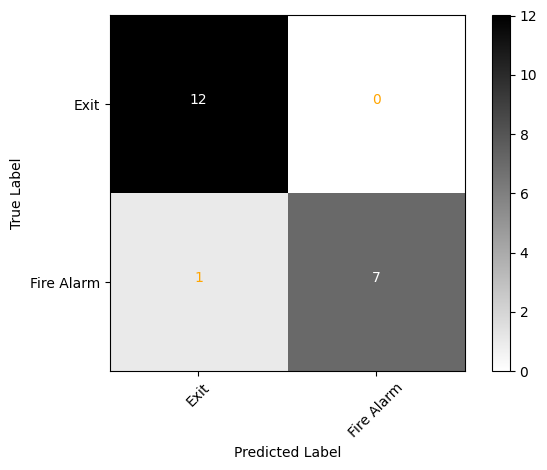

In [ ]:
show_confusion_matrix(cm)

In [ ]:
cm

array([[12,  0],
       [ 0,  8]])

In [ ]:
dd

(8, 12, 0, 0)

In [ ]:
cm

array([[12,  0],
       [ 0,  8]])

In [ ]:
cm[1][1]

8

In [ ]:
(cm, (tp, tn, fp, fn)) = create_confusion_matrix(conf_y_labels, conf_y_preds)
print(tp, tn, fp, fn)
show_confusion_matrix(cm)

In [ ]:
print(train_iou_scores)
print(train_localization_losses)
print(train_classification_accuracies)
print(train_classification_losses)

[0.8415909558534622, 0.8676851540803909, 0.8693626299500465]
[0.0009911017608828844, 0.0008646151050925255, 0.0008794821333140135]
[1.0, 1.0, 1.0]
[1.770070713291716e-06, 1.2919227572183444e-07, 6.17456576890163e-07]


In [ ]:
print(test_iou_scores)
print(test_localization_losses)
print(test_classification_accuracies)
print(test_classification_losses)

[0.8389893174171448, 0.8644734621047974, 0.8567438721656799]
[0.0010379260405898095, 0.001126046129502356, 0.0009261112893000246]
[1.0, 1.0, 1.0]
[8.106226232484914e-08, 6.854531022781885e-08, 3.933905361463985e-08]


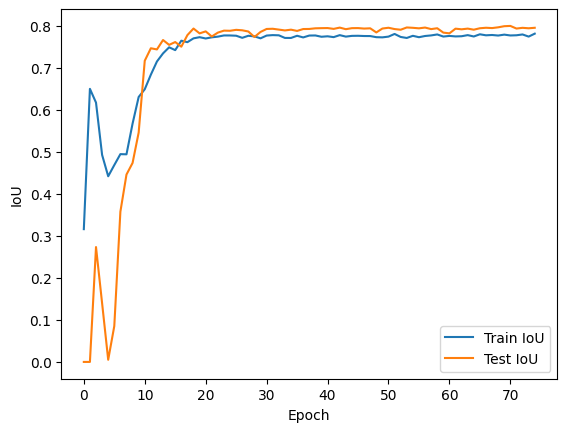

In [ ]:
import matplotlib.pyplot as plt

# Plot the training and testing loss over time
plt.plot(train_iou_scores, label='Train IoU')
plt.plot(test_iou_scores, label='Test IoU')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.show()

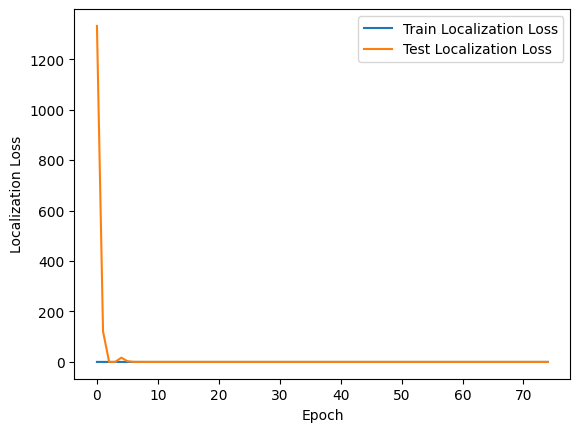

In [ ]:
# Plot the training and testing loss over time
plt.plot(train_localization_losses, label='Train Localization Loss')
plt.plot(test_localization_losses, label='Test Localization Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Localization Loss')
plt.show()

In [ ]:
train_

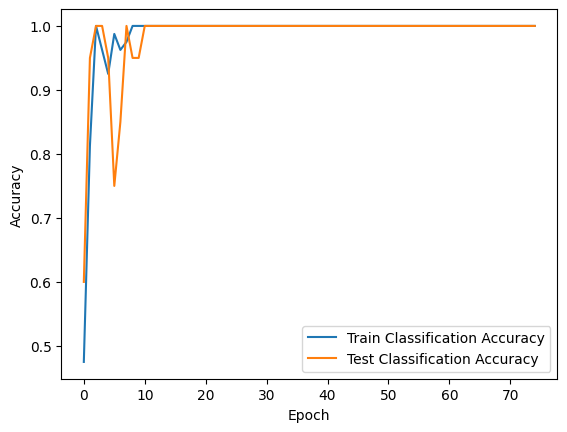

In [ ]:
# Plot the training and testing loss over time
plt.plot(train_classification_accuracies, label='Train Classification Accuracy')
plt.plot(test_classification_accuracies, label='Test Classification Accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

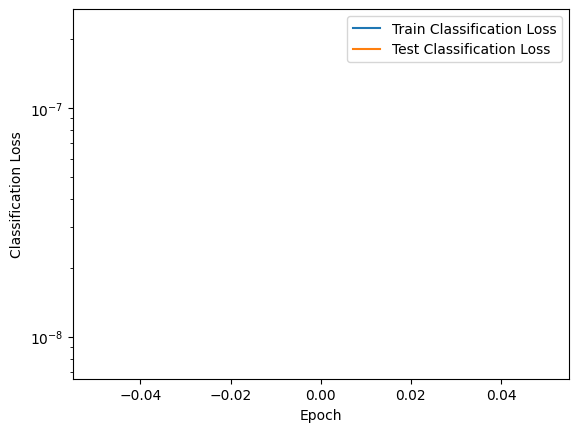

In [ ]:
# Plot the training and testing loss over time
plt.plot(train_classification_loss, label='Train Classification Loss')
plt.plot(test_classification_loss, label='Test Classification Loss')
plt.yscale('log')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Classification Loss')
plt.show()

**Saving Model Architecture & Weights**

In [ ]:
torch.save(concatenated_model, 'concat_model_all.pth')

In [ ]:
torch.save(concatenated_model.state_dict(), 'concat_model_weights.pth')

In [ ]:
compiled_concat_model = torch.jit.script(concatenated_model)

In [ ]:
from google.colab import files

In [ ]:
!ls

concat_model_all.pth	  jh_floor_signs.csv  sample_data
concat_model_weights.pth  resized_jh_signs


In [ ]:
files.download('concat_model_all.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

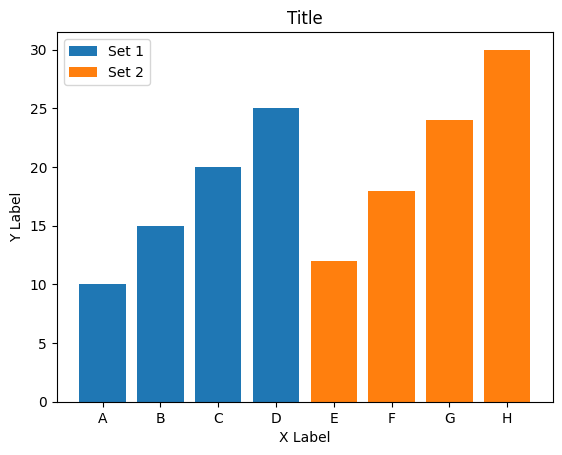

In [ ]:
import matplotlib.pyplot as plt

# Data for the first set of bars
bar1_x = ['A', 'B', 'C', 'D']
bar1_y = [10, 15, 20, 25]

# Data for the second set of bars
bar2_x = ['E', 'F', 'G', 'H']
bar2_y = [12, 18, 24, 30]

# Create a bar plot with two sets of bars
plt.bar(bar1_x, bar1_y, label='Set 1')
plt.bar(bar2_x, bar2_y, label='Set 2')

# Add a legend and labels to the plot
plt.legend()
plt.xlabel('X Label')
plt.ylabel('Y Label')
plt.title('Title')

# Show the plot
plt.show()

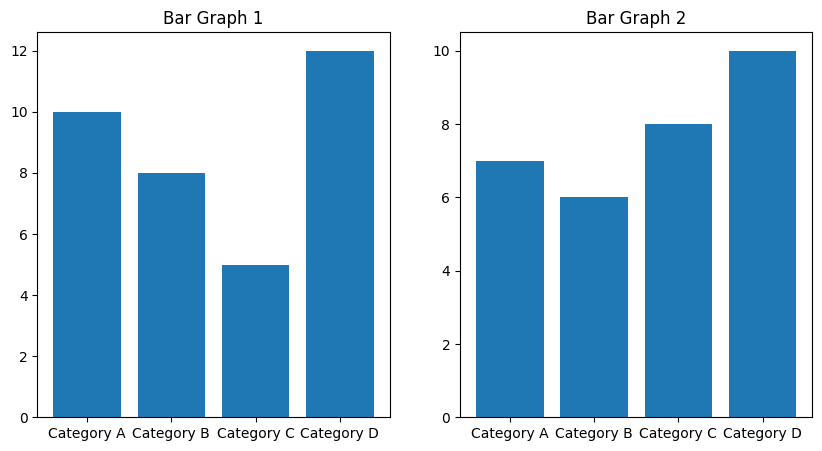

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some sample data
categories = ['Category A', 'Category B', 'Category C', 'Category D']
data1 = np.array([10, 8, 5, 12])
data2 = np.array([7, 6, 8, 10])

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot data on the first subplot
ax1.bar(categories, data1)
ax1.set_title('Bar Graph 1')

# Plot data on the second subplot
ax2.bar(categories, data2)
ax2.set_title('Bar Graph 2')

# Show the plot
plt.show()

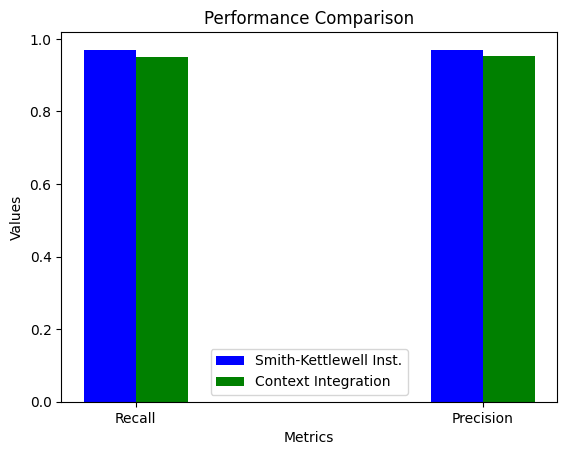

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate sample data
categories = ['Recall', 'Precision']
values1 = np.array([0.97, 0.97])
values2 = np.array([0.95, 0.9535])

# Set the width of each bar
bar_width = 0.15

# Set the x-coordinates for each group of bars
x_pos1 = np.arange(len(categories))
x_pos2 = x_pos1 + bar_width

# Create the plot
fig, ax = plt.subplots()
ax.bar(x_pos1, values1, bar_width, color='b', label='Smith-Kettlewell Inst.')
ax.bar(x_pos2, values2, bar_width, color='g', label='Context Integration')

# Add labels and title
ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Performance Comparison')
ax.set_xticks(x_pos1 + bar_width / 2)
ax.set_xticklabels(categories)
ax.legend()

plt.show()